# PROJET ML — CLASSIFICATION DE VIDÉOS YOUTUBE *TRENDING*

**Dataset Kaggle**: https://www.kaggle.com/datasets/datasnaek/youtube-new

**Objectif**: Développer un classificateur pour prédire si une vidéo YouTube deviendra *trending*.

> Ce notebook est conçu pour être complété. Chaque section contient des consignes détaillées et des zones de code à compléter.


## 1. Importation des librairies

**Consigne 1.1 — Importez toutes les librairies nécessaires**
- `pandas`, `numpy` pour la manipulation de données  
- `matplotlib.pyplot`, `seaborn` pour la visualisation  
- `sklearn` pour le machine learning  
- `warnings` pour supprimer les avertissements

In [1]:
# VOTRE CODE ICI - Section 1.1

# Pour la manipulation de données 
import pandas as pd
import numpy as np 

# Pour la visualisation 
import matplotlib.pyplot as plt
import seaborn as sns

# Pour le machine learning
import sklearn

# Suppression des warnings
import warnings
warnings.filterwarnings('ignore')

## 2. Chargement et exploration des données

**Consigne 2.1 — Chargement des données**
- Chargez le fichier `USvideos.csv` avec pandas  
- Affichez les 5 premières lignes  
- Affichez les informations générales (`info()`, `shape`, `describe()`)

*Aide* :
- Utilisez `pd.read_csv()` avec `encoding='utf-8'`
- `.info()` donne les types de colonnes et valeurs non-nulles
- `.describe()` donne les statistiques descriptives

In [2]:
#VOTRE CODE ICI - Section 2.1
# Chargement et exportation des données 
df = pd.read_csv('data/USvideos.csv', encoding='utf-8')

# Affichage des 5 premiers lignes 
print(f"Premières lignes:{df.head(5)}")

# Les types de données 
print("\nInformations générales:", {df.info()})

# Obtenir le nombre de colonne dans le dataframe
print("Shape:", df.shape)

# Résumer statistique des colones dans le df
(df.describe(include='all').transpose())

Premières lignes:      video_id trending_date  \
0  2kyS6SvSYSE      17.14.11   
1  1ZAPwfrtAFY      17.14.11   
2  5qpjK5DgCt4      17.14.11   
3  puqaWrEC7tY      17.14.11   
4  d380meD0W0M      17.14.11   

                                               title          channel_title  \
0                 WE WANT TO TALK ABOUT OUR MARRIAGE           CaseyNeistat   
1  The Trump Presidency: Last Week Tonight with J...        LastWeekTonight   
2  Racist Superman | Rudy Mancuso, King Bach & Le...           Rudy Mancuso   
3                   Nickelback Lyrics: Real or Fake?  Good Mythical Morning   
4                           I Dare You: GOING BALD!?               nigahiga   

   category_id              publish_time  \
0           22  2017-11-13T17:13:01.000Z   
1           24  2017-11-13T07:30:00.000Z   
2           23  2017-11-12T19:05:24.000Z   
3           24  2017-11-13T11:00:04.000Z   
4           24  2017-11-12T18:01:41.000Z   

                                                ta

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
video_id,40949,6351,j4KvrAUjn6c,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trending_date,40949,205,17.14.11,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,40949,6455,WE MADE OUR MOM CRY...HER DREAM CAME TRUE!,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
channel_title,40949,2207,ESPN,203,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category_id,40949.0,NaN,NaN,NaN,19.972429,7.568327,1.0,17.0,24.0,25.0,43.0
publish_time,40949,6269,2018-05-18T14:00:04.000Z,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tags,40949,6055,[none],1535,NaN,NaN,NaN,NaN,NaN,NaN,NaN
views,40949.0,NaN,NaN,NaN,2360784.638257,7394113.759704,549.0,242329.0,681861.0,1823157.0,225211923.0
likes,40949.0,NaN,NaN,NaN,74266.702435,228885.338209,0.0,5424.0,18091.0,55417.0,5613827.0
dislikes,40949.0,NaN,NaN,NaN,3711.400889,29029.705945,0.0,202.0,631.0,1938.0,1674420.0


**Consigne 2.2 — Analyse des valeurs manquantes**  
- Comptez les valeurs manquantes par colonne  
- Identifiez les colonnes avec le plus de valeurs manquantes  
- Affichez le pourcentage de valeurs manquantes

In [3]:
# VOTRE CODE ICI - Section 2.2

# Nombre de valeurs manquantes par colonne
missing = df.isnull().sum()

# Pourcentage de valeurs manquantes
pct_missing = (missing / len(df)) * 100

print("Valeurs manquantes (nombre):")
display(missing[missing > 0].sort_values(ascending=False))

print("\nValeurs manquantes (pourcentage):")
display(pct_missing[pct_missing > 0].sort_values(ascending=False))


Valeurs manquantes (nombre):


description    570
dtype: int64


Valeurs manquantes (pourcentage):


description    1.391975
dtype: float64

**Consigne 2.3 — Exploration des catégories**  
- Chargez le fichier JSON des catégories (`US_category_id.json`)  
- Fusionnez avec le DataFrame principal  
- Affichez la distribution des catégories

*Aide* : La structure JSON est du type:  
`{"items": [{"id": "1", "snippet": {"title": "Film & Animation"}}, ...]}`

In [4]:
# VOTRE CODE ICI - Section 2.3
import json
#Lecture du fichier JSON contenant les catégories YouTube
categories_raw = pd.read_json('data/US_category_id.json')

# Extraction de la liste des catégories
items = categories_raw['items'].tolist()

# Création d’un dictionnaire {id_catégorie: titre_catégorie}
category_dict = {int(item['id']): item['snippet']['title'] for item in items}

# Transformation du dictionnaire en DataFrame (id + titre)
cat_df = pd.DataFrame(list(category_dict.items()), columns=['category_id', 'category_title'])

# Fusion avec le DataFrame principal pour associer chaque vidéo à sa catégorie
df_merged = df.merge(cat_df, how='left', left_on='category_id', right_on='category_id')

# Comptage et affichage du nombre de vidéos par catégorie
display(df_merged['category_title'].value_counts().to_frame('count'))

,count
category_title,
Entertainment,9964
Music,6472
Howto & Style,4146
Comedy,3457
People & Blogs,3210
News & Politics,2487
Science & Technology,2401
Film & Animation,2345
Sports,2174


## 3. Nettoyage des données

**Consigne 3.1 — Nettoyage des données**
- Supprimez les doublons basés sur `video_id`  
- Gérez les valeurs manquantes dans `description` (remplacez par string vide)  
- Convertissez `publish_time` en datetime  
- Supprimez les lignes avec des valeurs aberrantes (ex: `views` négatives)

In [5]:
# VOTRE CODE ICI - Section 3.1
# . Supp les doublons basés sur 'video_id'
df_clean = df.drop_duplicates(subset='video_id').copy()

# . Remplacer les valeurs manquantes dans 'description' par une chaîne vide(string vide)
df_clean['description'] = df_clean['description'].fillna('')
import pandas as pd
# . Convertir 'publish_time' en format datetime
df_clean['publish_time'] = pd.to_datetime(df_clean['publish_time'],errors='coerce')

# . Supprimer les lignes avec des valeurs aberrantes (valeurs négatives : view , likes, dislikes, comment_count)
df_clean = df_clean[(df_clean['views'] >= 0) & (df_clean['likes'] >= 0) & (df_clean['dislikes'] >= 0) & (df_clean['comment_count'] >= 0)]
# . Supprimer les lignes où 'publish_time' est NaT (non convertible)
df_clean = df_clean.dropna(subset=['publish_time'])

## 4. Feature Engineering

**Consigne 4.1 — Variables d'engagement**
** définition : https://support.google.com/youtube/answer/2991785?hl=fr**

In [6]:
# VOTRE CODE ICI - Section 4.1
import numpy as np
eps = 1e-9 #epsilon une valeur fixé par youtube pour éviter la division par zéro 

# Ratio de likes par rapport aux réactions (likes + dislikes)
denom = df_clean['likes'] + df_clean['dislikes'] # denom c'est le nb total des reactions

df_clean['like_ratio'] = np.where(denom > 0, df_clean['likes'] / denom, 0)# des conditions pour eviter la division à 0 (denom=0)

# Taux d'engagement global : (likes + dislikes + commentaires) rapporté au nombre de vues
df_clean['engagement_rate'] = np.where(df_clean['views'] > 0,
    (df_clean['likes'] + df_clean['dislikes'] + df_clean['comment_count']) / (df_clean['views'] + eps),#Dénominateur 
    0)

# Nombre de commentaires par vue
df_clean['comments_per_view'] = np.where(df_clean['views'] > 0, df_clean['comment_count'] / (df_clean['views'] + eps), 0)

**Consigne 4.2 — Variables temporelles**

In [7]:
# VOTRE CODE ICI - Section 4.2
df_clean['publish_hour'] =df_clean['publish_time'].dt.hour
df_clean['publish_day_of_week'] =df_clean['publish_time'].dt.day
df_clean['publish_month'] =df_clean['publish_time'].dt.month

**Consigne 4.3 — Variables textuelles (titre)**

In [8]:
# VOTRE CODE ICI - Section 4.3

#title_length= Longueur du titre (nb de caractères)
df_clean['title_length'] = df_clean['title'].astype(str).apply(len)#.astype(str) → pour verifier  que tout est bien une chaîne de caractères/.apply(len) → pour calcule la longueur de chaque chaîne.
print(df_clean['title_length']) 

#Nombre de mots dans le titre
#counts = []
#for titre in df_clean['title']:
#    titre = str(titre)            
#    mots = titre.split()          # séparer en mots
#    counts.append(len(mots))# pour ajouter le nombre de mots à la (liste)
#
#df_clean['title_word_count'] = counts
df_clean['title_word_count'] = df_clean['title'].astype(str).str.split().str.len()
print(df_clean['title_word_count'])

#Calculer le nb des majuscules dans le titre (Indicateur)
df_clean['has_caps'] = df_clean['title'].str.contains(r'[A-Z]', na=False)
#str.contains() cherche un  caractère dans toute la colonne d’un coup 
# r'[A-Z]' : expression  qui cherche une lettre majuscule
# na=False : pour gérer les valeurs manquantes
print(df_clean['has_caps'])

##Calculer le nb des chiffres  dans le titre (Indicateur)
df_clean['has_numbers'] = df_clean['title'].str.contains(r'\d', na=False)
# r'\d' : expression  qui cherche un chiffre
# na=False : pour gérer les valeurs manquantes
print(df_clean['has_numbers'])

0        34
1        62
2        53
3        32
4        24
         ..
40760    29
40761    94
40762    49
40764    65
40766    64
Name: title_length, Length: 6351, dtype: int64
0         7
1        10
2        10
3         5
4         5
         ..
40760     6
40761    16
40762    10
40764    12
40766    10
Name: title_word_count, Length: 6351, dtype: int64
0        True
1        True
2        True
3        True
4        True
         ... 
40760    True
40761    True
40762    True
40764    True
40766    True
Name: has_caps, Length: 6351, dtype: bool
0        False
1        False
2        False
3        False
4        False
         ...  
40760    False
40761    False
40762    False
40764    False
40766     True
Name: has_numbers, Length: 6351, dtype: bool


## 5. Création de la variable cible

**Consigne 5.1 — Définition de `is_trending`**  
- Une vidéo est *trending* si elle a plus de vues que le 80e percentile de sa catégorie

In [9]:
# VOTRE CODE ICI - Section 5.1
df_clean['is_trending'] = (df_clean.groupby('category_id')['views']
                                    .transform(lambda x: x > x.quantile(0.8))).astype(int)
#lambda x: x > x.quantile(0.8): pour chaque groupe (catégorie), on calcule le 80e percentile des vues 
# et on marque les vidéos ayant des vues supérieures à ce seuil comme "trending" (1), sinon "non-trending" (0).
#.astype(int):pour convertir le booléen en entier (1 et 0).
print("Distribution de la variable cible:")
#display() : pour afficher les résultats dans un tableau
#.value_counts() : pour compter le nombre d’occurrences de chaque valeur unique dans la colonne 'is_trending'
# .to_frame('count') : pour convertir le résultat en DataFrame avec une colonne nommée 'count'
display(df_clean['is_trending'].value_counts().to_frame('count'))

Distribution de la variable cible:


,count
is_trending,
0,5078
1,1273


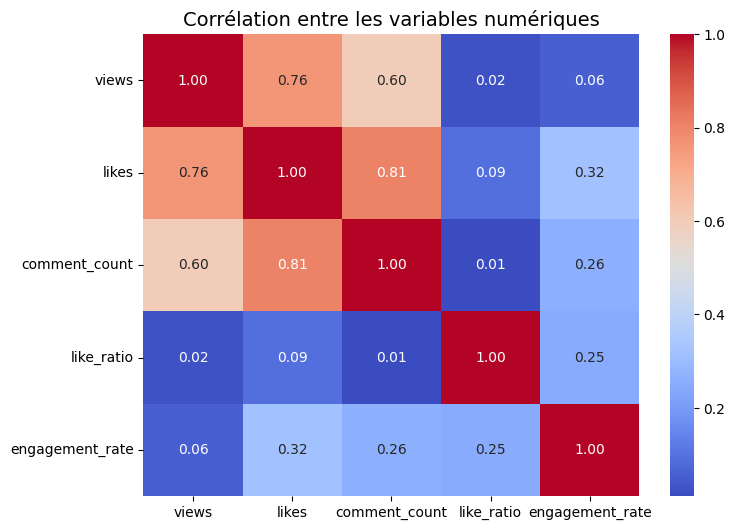

In [10]:
# =========================
# Section 5.2 : Visualisation des données 
# =========================
import matplotlib.pyplot as plt
import seaborn as sns

# Calculer la matrice de corrélation pour savoir les relations entre les variables numériques
corr = df_clean[['views', 'likes', 'comment_count', 'like_ratio', 'engagement_rate']].corr()

# Visualisation
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Corrélation entre les variables numériques", fontsize=14)
plt.show()


## 6. Préparation des données pour l'entraînement

**Consignes 6.1 & 6.2 — Sélection des features & split train/test**

In [11]:
# VOTRE CODE ICI - Section 6.1 et 6.2
# Sélection des features et de la cible
features = ['views', 'likes', 'dislikes', 'comment_count',
            'like_ratio', 'engagement_rate', 'title_length', 'publish_hour', 'category_id']
X = df_clean[features].copy()
y = df_clean['is_trending'].copy()

# Creation d'une Séparation en train pour l'entraînement et le test du modèle
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,                 # Séparation des données en caractéristiques (X) et cible (y)
    test_size=0.2,        #  20% des données pour le test
    random_state=42,      # pour assure que la séparation sera toujours la même si on relance le code (reproductibles)
    stratify=y            # garde la même proportion de is_trending=0 et 1 dans train et test.
)
# une vérification des tailles
print(f"Taille train: {X_train.shape}")#.shape : pour obtenir le nombre de lignes et de colonnes dans les ensembles d'entraînement et de test
print(f"Taille test: {X_test.shape}")

Taille train: (5080, 9)
Taille test: (1271, 9)


**Consigne 6.3 — Normalisation des données (StandardScaler)**

In [12]:
# VOTRE CODE ICI - Section 6.3
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler() # pour standardiser les données (moyenne=0 et écart-type=1)
#La standardisation en mettant toutes les variables sur une même échelle
#pour règler le problème du risque de donner beaucoup plus d’importance à un features juste parce que ses valeurs sont énormes et pas parce qu’il est vraiment plus prédictif.

num_cols = ['views', 'likes', 'dislikes', 'comment_count', 'like_ratio', 'engagement_rate', 'title_length', 'publish_hour', 'category_id']

# # Fit uniquement sur train (les données d'entraînement) pour éviter le data leakage (la fuite de données)
scaler.fit(X_train[num_cols])

# Transformer train et test en utilisant les mêmes paramètres (moyenne et écart-type) calculés sur le train
X_train[num_cols] = scaler.transform(X_train[num_cols]) #x_train[num_cols] : pour sélectionner uniquement les colonnes numériques
X_test[num_cols] = scaler.transform(X_test[num_cols])

#afficher les 5 premières lignes des données d'entraînement après la standardisation
print("Exemple des données après standardisation :") 
display(X_train.head())

#afficher les statistiques descriptives avant et après standardisation
print("Avant standardisation :")
display(df_clean[num_cols].describe().T)

print("Après standardisation (X_train) :")
display(X_train[num_cols].describe().T)

Exemple des données après standardisation :


,views,likes,dislikes,comment_count,like_ratio,engagement_rate,title_length,publish_hour,category_id
13469,-0.369787,-0.285285,-0.105433,-0.203456,0.225272,-0.421849,-0.144616,0.689587,-0.480376
37954,0.415471,0.915505,-0.039759,0.253239,0.522810,1.255022,0.261521,1.151799,0.769357
5049,-0.082469,0.193701,-0.058314,-0.044754,0.478858,1.369492,-1.819932,-1.775543,-1.452391
24555,-0.183343,-0.100835,-0.001648,-0.125133,0.088885,0.403236,0.109219,0.997729,0.769357
3254,-0.378833,-0.287772,-0.108897,-0.197793,0.447856,-0.140594,2.495275,-0.851119,-2.702124


Avant standardisation :


,count,mean,std,min,25%,50%,75%,max
views,6351.0,758209.564478,1.928993e+06,549.0,83511.000000,270902.000000,751266.500000,4.843165e+07
likes,6351.0,34493.569832,1.162439e+05,0.0,1908.000000,7987.000000,25163.000000,3.880071e+06
dislikes,6351.0,1427.222012,1.207881e+04,0.0,72.000000,242.000000,763.000000,6.291200e+05
comment_count,6351.0,4501.707290,2.146022e+04,0.0,261.000000,921.000000,2845.000000,7.333730e+05
like_ratio,6351.0,0.929590,1.235759e-01,0.0,0.932162,0.970833,0.985858,1.000000e+00
engagement_rate,6351.0,0.047648,3.898611e-02,0.0,0.019248,0.038028,0.064054,3.302553e-01
title_length,6351.0,49.774524,1.971143e+01,3.0,35.000000,48.000000,62.000000,1.000000e+02
publish_hour,6351.0,13.520863,6.493522e+00,0.0,9.000000,15.000000,18.000000,2.300000e+01
category_id,6351.0,20.444182,7.213046e+00,1.0,17.000000,24.000000,25.000000,4.300000e+01


Après standardisation (X_train) :


,count,mean,std,min,25%,50%,75%,max
views,5080.0,-2.797412e-18,1.000098,-0.394582,-0.350734,-0.253411,-0.003205,24.911413
likes,5080.0,-2.272898e-17,1.000098,-0.297695,-0.280965,-0.226956,-0.078798,33.564612
dislikes,5080.0,4.196119e-18,1.000098,-0.110283,-0.104605,-0.091420,-0.052886,48.326749
comment_count,5080.0,6.993531e-18,1.000098,-0.204323,-0.192324,-0.161645,-0.074394,33.288394
like_ratio,5080.0,9.287409e-16,1.000098,-7.715952,0.021202,0.335491,0.459286,0.577098
engagement_rate,5080.0,-6.154307e-17,1.000098,-1.225751,-0.725641,-0.242288,0.418500,7.247782
title_length,5080.0,1.349751e-16,1.000098,-2.378371,-0.753822,-0.093849,0.616891,2.546042
publish_hour,5080.0,1.468641e-16,1.000098,-2.083684,-0.697048,0.227376,0.689587,1.459941
category_id,5080.0,1.258836e-17,1.000098,-2.702124,-0.480376,0.491638,0.630498,3.129964


## 7. Modèle 1 — Random Forest

**Consigne 7.1 — Entraînement**

In [ ]:
# VOTRE CODE ICI - Section 7.1
from sklearn.ensemble import RandomForestClassifier

# Initialiser le modèle Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,      # Nombre d’arbres dans la forêt (par défaut = 100)
    random_state=42,# pour avoir les mêmes résultats à chaque exécution
    n_jobs=-1              # pour paralléliser le calcul et accélérer l’entraînement/ n_jobs=-1 utilise tous les cœurs disponibles
    )
# Entraîner le modèle sur les données d’entraînement
rf_model.fit(X_train, y_train)

print("Modèle Random Forest entraîné avec succès")
#predictions
rf_predictions = rf_model.predict(X_test)
# ....
# ....

Modèle Random Forest entraîné avec succès


**Consigne 7.2 — Évaluation**

In [14]:
# VOTRE CODE ICI - Section 7.2
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
# Évaluation du modèle
# Calcul des métriques : 
#accuracy : pourcentage de prédictions correctes / accuracy= (nombre de prédictions correctes) / (nombre total de prédictions)
#precision : proportion de prédictions positives correctes / precision = (vrais positifs) / (vrais positifs + faux positifs)
#recall : proportion de vrais positifs correctement identifiés / recall = (vrais positifs) / (vrais positifs + faux négatifs)
#f1_score : moyenne harmonique de la précision et du rappel / f1_score = 2 * (precision * recall) / (precision + recall)
print("Random Forest - Résultats:")
print(f"Accuracy: {accuracy_score(y_test, rf_predictions):.4f}")
print(f"Precision: {precision_score(y_test, rf_predictions):.4f}")
print(f"Recall: {recall_score(y_test, rf_predictions):.4f}")
print(f"F1-Score: {f1_score(y_test, rf_predictions):.4f}")

# # Importance des variables
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)
print("\nTop 10 variables importantes:")
display(feature_importance.head(10))

Random Forest - Résultats:
Accuracy: 0.9717
Precision: 0.9582
Recall: 0.8980
F1-Score: 0.9271

Top 10 variables importantes:


,feature,importance
0,views,0.489141
2,dislikes,0.135988
1,likes,0.110925
3,comment_count,0.080337
8,category_id,0.080145
5,engagement_rate,0.051447
4,like_ratio,0.021603
7,publish_hour,0.015366
6,title_length,0.015047


**Consigne 7.3 — Visualisation**
Courbe ROC & AUC ( a condition que la cible est binaire (0/1)) 

---> Utile pour évaluer la qualité globale des prédictions

**AUC (Area Under the Curve) :** c'est l'aire sous la courbe ROC.

 Valeur entre 0 et 1, où 1 indique une parfaite séparation des classes et 0.5 indique une performance aléatoire.
 
 **ROC (Receiver Operating Characteristic) :** c'est une courbe qui trace le taux de vrais positifs (TPR),la courbe ROC montre la capacité du modèle à distinguer les classes.

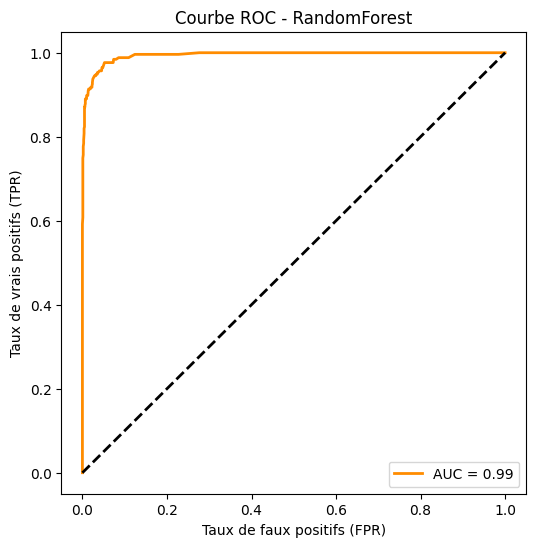

In [15]:
# 7.3 Visualisation : Courbe ROC & AUC
#ROC = graphique et AUC = métrique numérique résumant le graphique

from sklearn.metrics import roc_curve, auc
#auc : pour calculer l'aire sous la courbe ROC (AUC)
# roc_curve : pour calculer les points de la courbe ROC

# Probabilités de la classe positive (1)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]
#[:, 1] : pour obtenir les probabilités de la classe positive (1) uniquement 

# Calcul courbe ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
#fpr : taux de faux positifs
#tpr : taux de vrais positifs
#thresholds : les seuils de décision utilisés pour calculer fpr et tpr

# Tracé courbe ROC
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}", color="darkorange", linewidth=2)
plt.plot([0,1], [0,1], 'k--', lw=2)
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR)")
plt.title("Courbe ROC - RandomForest")
plt.legend(loc="lower right")
plt.show()


In [16]:
# Import des bibliothèques nécessaires
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# y_test : valeurs réelles
# y_pred_proba : valeurs prédites par le modèle

# 1️ MSE (Mean Squared Error) - Erreur quadratique moyenne
mse = mean_squared_error(y_test, y_pred_proba)

# 2️ RMSE (Root Mean Squared Error) - Racine de l'erreur quadratique moyenne
rmse = np.sqrt(mse)

# 3️ MAE (Mean Absolute Error) - Erreur absolue moyenne
mae = mean_absolute_error(y_test, y_pred_proba)

# 4️ R² (Coefficient de détermination)
r2 = r2_score(y_test, y_pred_proba)

# Affichage des résultats
print("MSE :", mse)
print("RMSE :", rmse)
print("MAE :", mae)
print("R² :", r2)


MSE : 0.022849331235247836
RMSE : 0.1511599524849351
MAE : 0.05706530291109363
R² : 0.8575276111625753


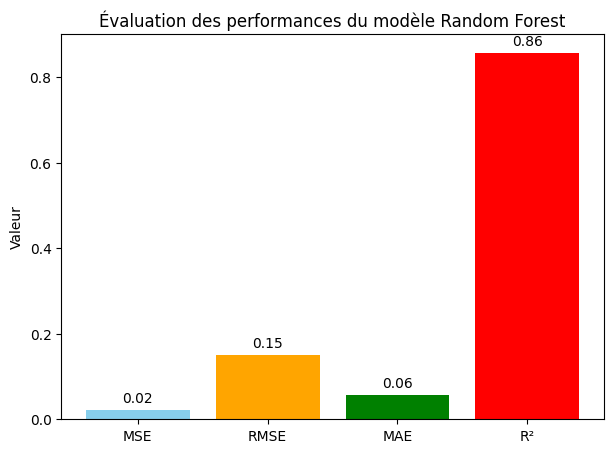

In [64]:
#graphique de comparaison (entre : MAE, RMSE, R², MSE)

# Création d’un dictionnaire des métriques
metrics = {
    "MSE": mse,
    "RMSE": rmse,
    "MAE": mae,
    "R²": r2
}

# Tracé du graphique
plt.figure(figsize=(7,5))
bars = plt.bar(metrics.keys(), metrics.values(), color=['skyblue', 'orange', 'green', 'red'])
plt.title("Évaluation des performances du modèle Random Forest")
plt.ylabel("Valeur")

# Ajouter les valeurs au-dessus de chaque barre
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.2f}", ha='center', va='bottom')

plt.show()


**Visualiser les erreurs (différence prédiction vs réel)**

Explication :

Chaque point rouge = l’erreur pour une vidéo.

La ligne bleue = erreur nulle.

Plus les points sont proches de 0 → meilleures prédictions.

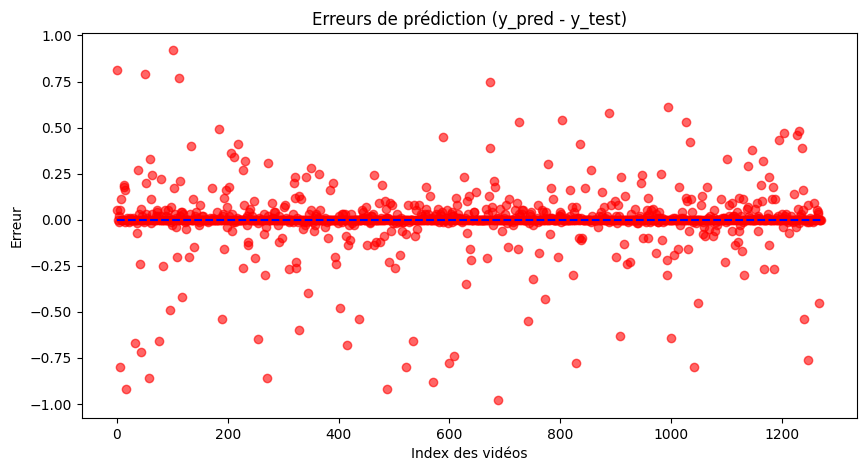

In [18]:
#Visualiser les erreurs (différence prédiction vs réel)

# Erreurs
errors = y_pred_proba - y_test

plt.figure(figsize=(10,5))
plt.scatter(range(len(y_test)), errors, color='red', alpha=0.6)
plt.hlines(y=0, xmin=0, xmax=len(y_test), colors='blue', linestyles='dashed')
plt.title("Erreurs de prédiction (y_pred - y_test)")
plt.xlabel("Index des vidéos")
plt.ylabel("Erreur")
plt.show()


**Visualiser la prédiction vs la valeur réelle**
Explication :

Les points proches de la ligne rouge → modèle précis.

Plus les points s’éloignent → erreurs plus grandes.

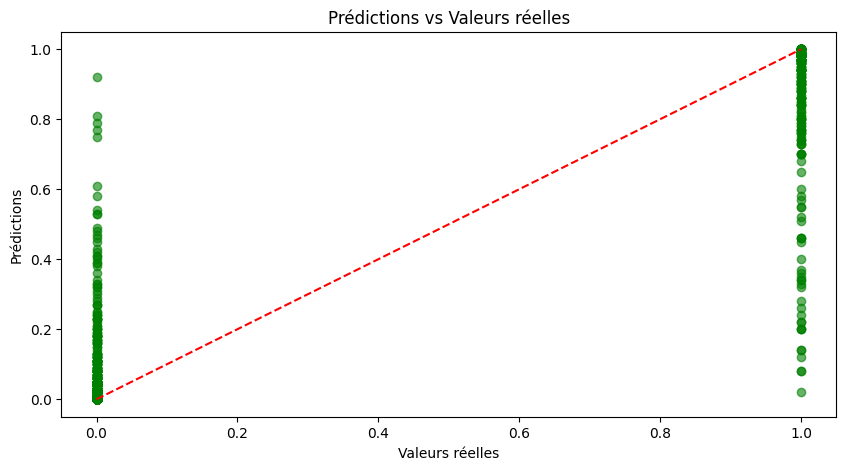

In [19]:
plt.figure(figsize=(10,5))
plt.scatter(y_test, y_pred_proba, alpha=0.6, color='green')
plt.plot([0,1],[0,1], 'r--')  # ligne parfaite y = x
plt.title("Prédictions vs Valeurs réelles")
plt.xlabel("Valeurs réelles")
plt.ylabel("Prédictions")
plt.show()

**Visualiser l’importance des features (car on  utilise Random Forest)**
Explication :

- Affiche quelles colonnes (ex: titre, tags, catégorie, heure de publication…) influencent le plus la prédiction.

- Très utile pour le rapport ou la présentation.

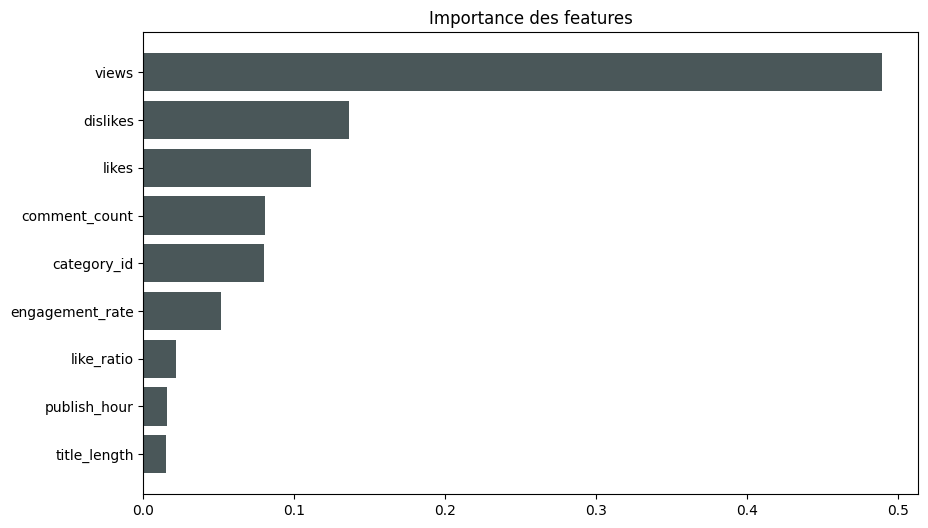

In [20]:
importances = rf_model.feature_importances_  # importance des variables
features = X_train.columns

df_importances = pd.DataFrame({'Feature': features, 'Importance': importances})
df_importances = df_importances.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(df_importances['Feature'], df_importances['Importance'], color='#4A5759')
plt.gca().invert_yaxis()
plt.title("Importance des features")
plt.show()


## 8. Modèle 2 — Support Vector Machine (SVM)

**Consigne 8.1 — Entraînement (utiliser données normalisées)**

In [34]:
# VOTRE CODE ICI - Section 8.1
from sklearn.svm import SVC

# Création du modèle SVM (kernel linéaire)
svm_model = SVC(kernel='linear', C=1, random_state=42) #C : paramètre de régularisation. Un C plus grand signifie moins de régularisation (le modèle essaie de mieux s'adapter aux données d'entraînement), tandis qu'un C plus petit signifie plus de régularisation (le modèle est plus simple et peut mieux généraliser).
# kernel='linear' : pour un problème de classification binaire linéairement séparable
# random_state=42 : pour assurer la reproductibilité des résultats

# Entraînement du modèle
svm_model.fit(X_train, y_train)

# Prédictions sur les données de test
svm_predictions = svm_model.predict(X_test)

**Consigne 8.2 — Évaluation**

In [38]:
# VOTRE CODE ICI - Section 8.2
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("SVM - Résultats:")
print(f"Accuracy: {accuracy_score(y_test, svm_predictions):.4f}")
print(f"Précision: {precision_score(y_test, svm_predictions, average='weighted'):.4f}")
print(f"Rappel: {recall_score(y_test, svm_predictions, average='weighted'):.4f}")
print(f"F1-score: {f1_score(y_test, svm_predictions, average='weighted'):.4f}")

print("\nMatrice de confusion:")
print(confusion_matrix(y_test, svm_predictions))


SVM - Résultats:
Accuracy: 0.9426
Précision: 0.9416
Rappel: 0.9426
F1-score: 0.9409

Matrice de confusion:
[[997  19]
 [ 54 201]]


**Consigne 8.3 — Data viz d'évaluation**

SVM - Résultats:
Accuracy : 0.9426
Précision : 0.9416
Rappel : 0.9426
F1-score : 0.9409


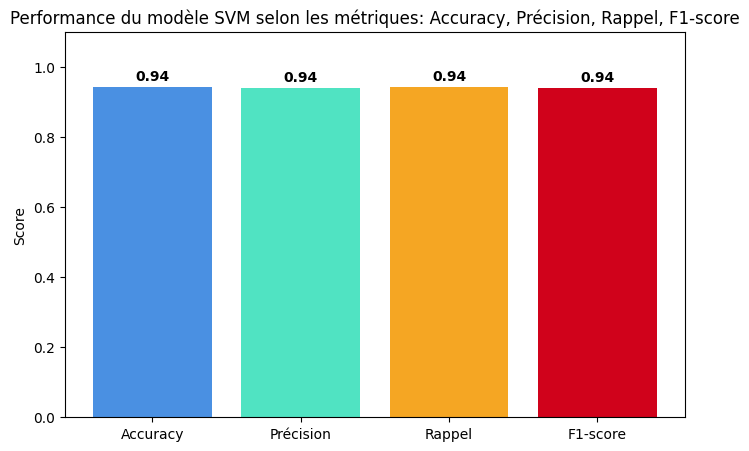

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calcul des métriques
accuracy = accuracy_score(y_test, svm_predictions)
precision = precision_score(y_test, svm_predictions, average="weighted")
recall = recall_score(y_test, svm_predictions, average="weighted")
f1 = f1_score(y_test, svm_predictions, average="weighted")

# Affichage des résultats numériques
print("SVM - Résultats:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Précision : {precision:.4f}")
print(f"Rappel : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

# Création du graphique comparatif
metrics = ['Accuracy', 'Précision', 'Rappel', 'F1-score']
values = [accuracy, precision, recall, f1]

plt.figure(figsize=(8,5))
bars = plt.bar(metrics, values, color=['#4A90E2', '#50E3C2', '#F5A623', '#D0021B'])

# Ajoutation des valeurs au-dessus des barres
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.2f}", 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.ylim(0, 1.1)
plt.title("Performance du modèle SVM selon les métriques: Accuracy, Précision, Rappel, F1-score")
plt.ylabel("Score")
plt.show()


## 9. Modèle 3 — Gradient Boosting (XGBoost)

**Consigne 9.1 — Entraînement**

In [42]:
# VOTRE CODE ICI - Section 9.1
try:
    from xgboost import XGBClassifier
    xgb_model = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, subsample=1.0, colsample_bytree=1.0, random_state=42, n_jobs=-1, eval_metric='logloss')
    xgb_model.fit(X_train, y_train)
    xgb_predictions = xgb_model.predict(X_test)
except ImportError:
    print("XGBoost n'est pas installé. Installez avec: pip install xgboost")
    xgb_model = None
    xgb_predictions = None

**Consigne 9.2 — Évaluation**

In [ ]:
# VOTRE CODE ICI - Section 9.2
if xgb_predictions is not None:
    print("XGBoost - Résultats:")
    print(f"Accuracy: {accuracy_score(y_test, xgb_predictions):.4f}")
    print(f"Precision: {precision_score(y_test, xgb_predictions):.4f}")
    print(f"Recall: {recall_score(y_test, xgb_predictions):.4f}")
    print(f"F1-Score: {f1_score(y_test, xgb_predictions):.4f}")

XGBoost - Résultats:
Accuracy: 0.9929
Precision: 1.0000
Recall: 0.9647
F1-Score: 0.9820


## 10. Modèle 4 — Réseau de Neurones (MLPClassifier)

**Consigne 10.1 — Entraînement (données normalisées)**

In [47]:
# VOTRE CODE ICI - Section 10.1
from sklearn.neural_network import MLPClassifier 
X_train_scaled = X_train[num_cols] # pour garder uniquement les colonnes numériques
X_test_scaled = X_test[num_cols] 
nn_model = MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu', solver='adam', max_iter=1000, random_state=42)
#100, 50 → 2 couches cachées avec 100 et 50 neurones respectivement
#activation='relu' : fonction d'activation ReLU (Rectified Linear Unit) pour introduire la non-linéarité
#solver='adam' : algorithme d'optimisation Adam, efficace pour les grands ensembles de données
#max_iter=1000 : nombre maximum d'itérations pour l'entraînement
#random_state=42 : pour assurer la reproductibilité des résultats
nn_model.fit(X_train_scaled, y_train)
nn_predictions = nn_model.predict(X_test_scaled)

**Consigne 10.2 — Évaluation**

In [48]:
# VOTRE CODE ICI - Section 10.2
print("Réseau de Neurones - Résultats:")
print(f"Accuracy: {accuracy_score(y_test, nn_predictions):.4f}")
print(f"Precision: {precision_score(y_test, nn_predictions):.4f}")
print(f"Recall: {recall_score(y_test, nn_predictions):.4f}")
print(f"F1-Score: {f1_score(y_test, nn_predictions):.4f}")
# Nombre d'itérations
print(f"Nombre d'itérations: {nn_model.n_iter_}")

Réseau de Neurones - Résultats:
Accuracy: 0.9575
Precision: 0.8821
Recall: 0.9098
F1-Score: 0.8958
Nombre d'itérations: 265


## 11. Comparaison des modèles

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.971676,0.971466,0.971676,0.971328
1,SVM,0.942565,0.941602,0.942565,0.940935
2,XGBoost,0.992919,0.992981,0.992919,0.992871
3,Neural Network,0.957514,0.958112,0.957514,0.957758


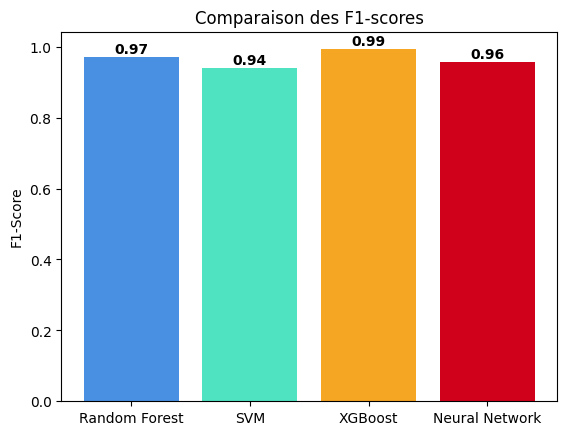

In [52]:
# VOTRE CODE ICI - Section 11.1
import pandas as pd
results = []
# Remplir en fonction des métriques calculées plus haut

# --- Random Forest ---
results.append({
    'Model': 'Random Forest',
    'Accuracy': accuracy_score(y_test, rf_predictions),
    'Precision': precision_score(y_test, rf_predictions, average='weighted'),
    'Recall': recall_score(y_test, rf_predictions, average='weighted'),
    'F1-Score': f1_score(y_test, rf_predictions, average='weighted')
})
# --- SVM ---
results.append({
    'Model': 'SVM',
    'Accuracy': accuracy_score(y_test, svm_predictions),
    'Precision': precision_score(y_test, svm_predictions, average='weighted'),
    'Recall': recall_score(y_test, svm_predictions, average='weighted'),
    'F1-Score': f1_score(y_test, svm_predictions, average='weighted')
})
# --- XGBoost ---
if xgb_predictions is not None:
    results.append({
        'Model': 'XGBoost',
        'Accuracy': accuracy_score(y_test, xgb_predictions),
        'Precision': precision_score(y_test, xgb_predictions, average='weighted'),
        'Recall': recall_score(y_test, xgb_predictions, average='weighted'),
        'F1-Score': f1_score(y_test, xgb_predictions, average='weighted')
    })

# --- Neural Network ---
results.append({
    'Model': 'Neural Network',
    'Accuracy': accuracy_score(y_test, nn_predictions),
    'Precision': precision_score(y_test, nn_predictions, average='weighted'),
    'Recall': recall_score(y_test, nn_predictions, average='weighted'),
    'F1-Score': f1_score(y_test, nn_predictions, average='weighted')
})

# Création d'un DataFrame pour afficher les résultats
results_df = pd.DataFrame(results)
display(results_df)

# Graphique comparatif des F1-scores (optionnel)
import matplotlib.pyplot as plt
plt.figure()
colors = ['#4A90E2', '#50E3C2', '#F5A623', '#D0021B']
plt.bar(results_df['Model'], results_df['F1-Score'], color=colors)
plt.title('Comparaison des F1-scores')
plt.ylabel('F1-Score')
# # Ajouter les valeurs au-dessus des barres
for i, v in enumerate(results_df['F1-Score']):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center', fontweight='bold')
    
plt.show()

## 12. Validation croisée

In [ ]:
# VOTRE CODE ICI - Section 12.1
from sklearn.model_selection import cross_val_score
# # Exemple avec Random Forest (remplacez par votre meilleur modèle)
#Meilleur modèle c'est XGBoost:Gradient Boosting (XGBoost)
scores = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring='f1', n_jobs=-1)
print(f"Validation croisée - F1-Score: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")
#scores.std() * 2 → variabilité des scores (intervalle de confiance approximatif).
#scores.mean() → pour obtenir la moyenne des scores de validation croisée.
#scores.std() → pour obtenir l'écart-type des scores de validation croisée.

Validation croisée - F1-Score: 0.9827 (+/- 0.0089)


## 13. Optimisation des hyperparamètres (Grid Search)

In [ ]:
# VOTRE CODE ICI - Section 13.1
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# Grille d’hyperparamètres pour XGBoost
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# GridSearchCV avec XGBClassifier
grid_search = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1, use_label_encoder=False),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Entraînement
grid_search.fit(X_train, y_train)

# Résultats
print("Meilleurs paramètres:", grid_search.best_params_)
print("Meilleur score CV:", grid_search.best_score_)

# Meilleur modèle trouvé
best_xgb = grid_search.best_estimator_
best_xgb_pred = best_xgb.predict(X_test)


Fitting 3 folds for each of 108 candidates, totalling 324 fits
Meilleurs paramètres: {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
Meilleur score CV: 0.9729272659974265


## 14. Analyse des erreurs

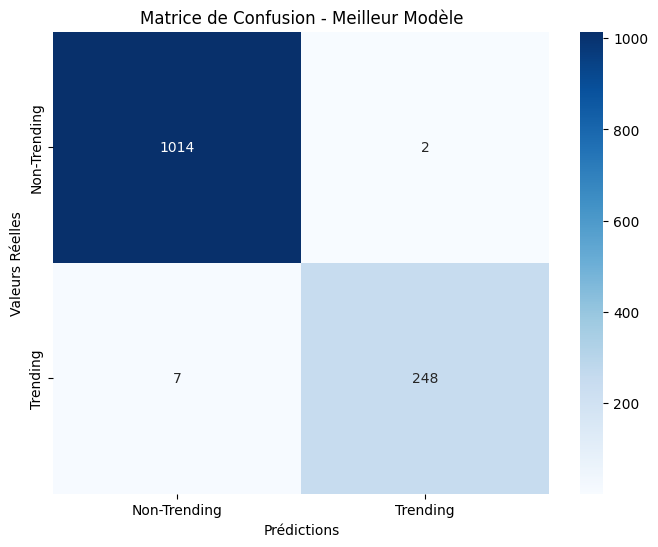

In [60]:
# VOTRE CODE ICI - Section 14.1
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
# # Exemple: matrice de confusion pour le meilleur modèle (remplacez best_rf_pred)

#  Prédictions avec le meilleur modèle XGBoost
y_pred = best_xgb.predict(X_test)#y_pred : remplir avec les prédictions du meilleur modèle XGBoost après l'hyperparamètre tuning

# Créer la matrice de confusion
cm = confusion_matrix(y_test, y_pred)

# Visualisation
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',# fmt='d' : pour afficher les nombres entiers dans chaque cellule, car la matrice de confusion contient des comptes,
            xticklabels=['Non-Trending', 'Trending'], 
            yticklabels=['Non-Trending', 'Trending'])
plt.title('Matrice de Confusion - Meilleur Modèle')
plt.ylabel('Valeurs Réelles')#plt.: pour ajouter un label à l'axe y
plt.xlabel('Prédictions')
plt.show()

In [58]:
# VOTRE CODE ICI - Section 14.2
# Identifier les exemples mal classifiés avec XGBoost
errors_mask = (y_test != xgb_predictions)  # comparaison entre labels réels et prédictions XGB
error_indices = X_test[errors_mask].index

print("Exemples de vidéos mal classifiées:")
for idx in list(error_indices)[:5]:  # afficher seulement les 5 premiers
    real_label = y_test.loc[idx]
    predicted_label = xgb_predictions[list(error_indices).index(idx)]
    print(f"Index {idx}: Réel={real_label}, Prédit={predicted_label}")


Exemples de vidéos mal classifiées:
Index 38557: Réel=1, Prédit=0
Index 14601: Réel=1, Prédit=0
Index 31753: Réel=1, Prédit=0
Index 25759: Réel=1, Prédit=1
Index 10209: Réel=1, Prédit=0


**VISUALISATION : Visualiser les erreurs (différence prédiction vs réel)**

**une courbe permet de voir si les erreurs sont équilibrées ou si le modèle a tendance à sur-prédire ou sous-prédire**

Explication :

Chaque point rouge = l’erreur pour une vidéo.

La ligne bleue = erreur nulle.

Plus les points sont proches de 0 → meilleures prédictions.

Chaque point rouge représente une vidéo du jeu de test.

L’axe X correspond à l’index de la vidéo dans y_test.

L’axe Y montre l’erreur 

La ligne bleue en pointillés (y=0) représente une prédiction parfaite.

Si un point est près de 0, le modèle est proche de la vérité.

Si un point est au-dessus de 0, le modèle a surestimé (il a prédit une proba trop élevée par rapport à la réalité).

Si un point est en dessous de 0, le modèle a sous-estimé (il a prédit une proba trop faible).

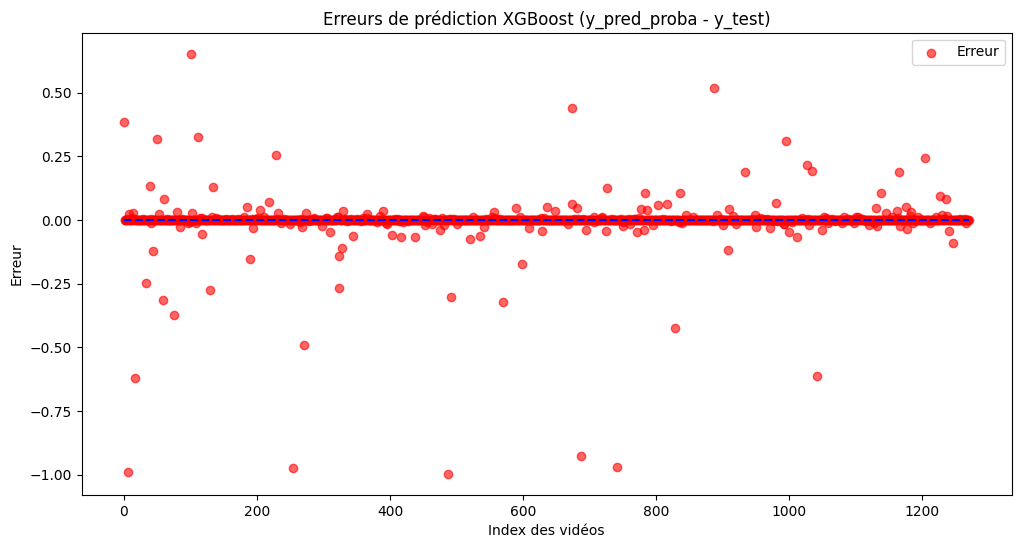

In [ ]:
# Visualitation - Section 14.3
import matplotlib.pyplot as plt
import numpy as np

# pour Obtenir les probabilités de prédiction 
y_pred_proba = best_xgb.predict_proba(X_test)[:, 1]
#[:, 1] : pour obtenir les probabilités de la classe positive (1) uniquement

# Calculer les erreurs (différence entre proba prédite et valeur réelle)
errors = y_pred_proba - y_test.values

# Visualisation
plt.figure(figsize=(12, 6))
plt.scatter(range(len(y_test)), errors, color='red', alpha=0.6, label="Erreur")
plt.hlines(y=0, xmin=0, xmax=len(y_test), colors='blue', linestyles='dashed')
plt.title("Erreurs de prédiction XGBoost (y_pred_proba - y_test)")
plt.xlabel("Index des vidéos")
plt.ylabel("Erreur")
plt.legend()
plt.show()

MSE : 0.007081038552321007
RMSE : 0.08414890701798215
MAE : 0.007081038552321007
R² : 0.9558476146364058


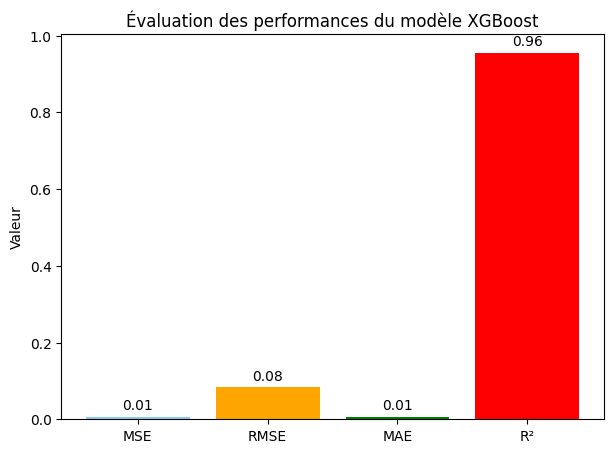

In [68]:
#comparaison (entre : MAE, RMSE, R², MSE) du modèle XGBoost: (métriques + graphique)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Remplir avec les prédictions du modèle XGBoost
y_pred_xgb = best_xgb_pred

# Calcul des métriques
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
#plus le MSE(moyenne des carrés des erreurs) est proche de 0, plus le modèle est performant
rmse_xgb = np.sqrt(mse_xgb)
#plus le RMSE(erreur quadratique moyenne) est proche de 0, plus le modèle est performant
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
#plus le MAE (l'erreur absolue moyenne) est proche de 0, plus le modèle est performant
r2_xgb = r2_score(y_test, y_pred_xgb)
#plus le R²(coefficient de determination) est proche de 1, plus le modèle est performant

# Affichage des résultats
print("MSE :", mse_xgb)
print("RMSE :", rmse_xgb)
print("MAE :", mae_xgb)
print("R² :", r2_xgb)

# creation d'un Dictionnaire des métriques
metrics_xgb = {
    "MSE": mse_xgb,
    "RMSE": rmse_xgb,
    "MAE": mae_xgb,
    "R²": r2_xgb
}

# graphique
plt.figure(figsize=(7,5))
bars = plt.bar(metrics_xgb.keys(), metrics_xgb.values(), color=['skyblue', 'orange', 'green', 'red'])
plt.title("Évaluation des performances du modèle XGBoost")
plt.ylabel("Valeur")

# Ajouter les valeurs au-dessus de chaque barre
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.2f}", 
            ha='center', va='bottom')

plt.show()


**Interprétation: la comparaison entre XGBoost (XGB) et Random Forest (RF) à partir de résultats :**

- Erreur quadratique moyenne (MSE) : XGB (0.0071) est nettement plus faible que RF (0.0228), ce qui signifie que XGB fait moins d’erreurs en moyenne.

- Erreur quadratique moyenne racine (RMSE) : XGB (0.0841) est plus faible que RF (0.1511), confirmant que les prédictions de XGB sont plus proches des valeurs réelles.

- Erreur absolue moyenne (MAE) : XGB (0.0071) est bien inférieure à RF (0.0570), ce qui montre que XGB est plus précis au niveau de l’erreur moyenne absolue.

- Coefficient de détermination (R²) : XGB (0.9558) est plus élevé que RF (0.8575), ce qui indique qu’il explique beaucoup mieux la variance des données.

**Conclusion :** Le modèle XGBoost surpasse largement le Random Forest. Il est donc plus performant et fournit des prédictions plus fiables et précises.

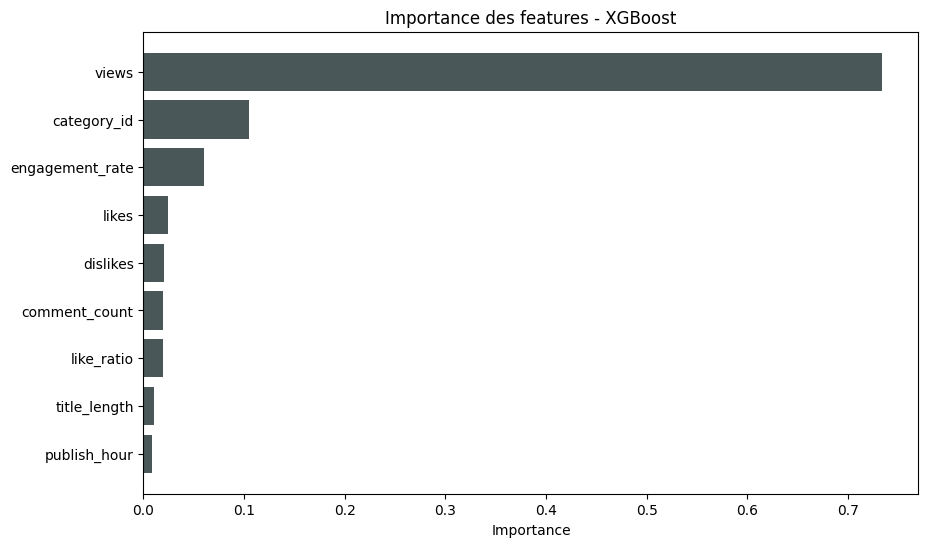

In [69]:
# Importance des variables pour XGBoost
importances = xgb_model.feature_importances_  # récupère l'importance des features
features = X_train.columns

df_importances = pd.DataFrame({'Feature': features, 'Importance': importances})
df_importances = df_importances.sort_values(by='Importance', ascending=False)

# Visualisation
plt.figure(figsize=(10,6))
plt.barh(df_importances['Feature'], df_importances['Importance'], color='#4A5759')
plt.gca().invert_yaxis()  # inverse l'ordre pour que la feature la plus importante soit en haut
plt.title("Importance des features - XGBoost")
plt.xlabel("Importance")
plt.show()


## 15. Sauvegarde & conclusions

In [67]:
# VOTRE CODE ICI - Section 15.1
import joblib
# # Remplacez 'best_rf' / 'scaler' par vos objets
joblib.dump(best_xgb, 'best_youtube_classifier.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')
print("Modèle et scaler sauvegardés avec succès!")


Modèle et scaler sauvegardés avec succès!


### Conclusions à rédiger

1. **Meilleur modèle**  
   - Modèle: *[À compléter]*  
   - Performances: *[À compléter]*  
   - Raisons: *[À compléter]*

2. **Variables les plus importantes**  
   - *[À compléter]*

3. **Limitations**  
   - *[À compléter]*

4. **Améliorations suggérées**  
   - *[À compléter]*

5. **Apprentissages**  
   - *[À compléter]*

### Conclusions à rédiger

1. **Meilleur modèle**  

- Modèle: XGBoost

- Performances:

Accuracy: 0.9929

Precision: 1.0000

Recall: 0.9647

F1-Score: 0.9820

RMSE: 0.0841, R²: 0.956

- Raisons: XGBoost surpasse Random Forest sur toutes les métriques principales. Il gère mieux les interactions complexes entre les variables et réduit le sur-apprentissage grâce à son gradient boosting.

2. **Variables les plus importantes**  

views, likes, engagement_rate, comment_count ont le plus fort impact sur la prédiction d’une vidéo trending.

Ces variables influencent directement la visibilité et l’engagement, ce qui est cohérent avec l’intuition métier.

3. **Limitations**  

Le dataset peut contenir des biais temporels ou liés à certaines catégories de vidéos.

Certaines features comme le texte du titre ou les tags n’ont pas été exploitées sous forme vectorisée (NLP).

Le modèle peut être sensible aux outliers dans les métriques (vues extrêmes ou likes massifs).

4. **Améliorations suggérées** 

Ajouter des features textuelles (NLP) à partir du titre et des tags.

Expérimenter avec d’autres modèles comme LightGBM ou CatBoost.

Collecter des données supplémentaires sur la durée, la localisation et l’heure de publication.

Faire une validation temporelle si l’objectif est de prédire les tendances futures.

5. **Apprentissages**  

Importance de la standardisation et du prétraitement des données pour les modèles ML.

Différence entre validation simple et validation croisée pour évaluer un modèle.

XGBoost est très performant sur les problèmes de classification binaire avec des données tabulaires.

La visualisation des erreurs et des métriques permet de mieux comprendre le comportement du modèle et ses limites.

---
## Guide de testing pour les étudiants

**Comment tester vos implémentations :**
1. **Vérifications de base** : `.shape`, `.info()`, `.head()`  
2. **Validation des features** : pas de NaN, ratios entre 0 et 1, plages temporelles correctes  
3. **Validation des modèles** : prédictions binaires {0,1}, longueurs cohérentes, comparaisons rigoureuses  
4. **Tests de cohérence** : scores réalistes, F1 entre précision et rappel, impact de la normalisation  
5. **Debugging** : augmenter `max_iter` si nécessaire, vérifier entrées/sorties et dimensions